# Lab 4: Position Control Analysis

**Learning Goals**
- Construct a closed-loop transfer function.
- Plot the step response of a closed-loop transfer function.
- Identify the poles of a closed-loop transfer function.
- Assess the stability of a closed-loop transfer function.

## MathWorks license statement

Lab content was adapted to Python from the Virtual Controls Laboratory developed by Mathworks.

Please find the license statement below:

Copyright (c) 2023, The MathWorks, Inc.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
      notice, this list of conditions and the following disclaimer.
    * Redistributions in binary form must reproduce the above copyright
      notice, this list of conditions and the following disclaimer in
      the documentation and/or other materials provided with the distribution
    * Neither the name of the The MathWorks, Inc. nor the names
      of its contributors may be used to endorse or promote products derived
      from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE
ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE
LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR
CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF
SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS
INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN
CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE)
ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE
POSSIBILITY OF SUCH DAMAGE.


In the previous lab, the motor position PID controller was tuned manually. For simple systems, this method can produce acceptable results. In complex systems, however, manual tuning can become very challenging. Mathematical models offer insight into the system dynamics, leading to improved controller design. In this lab, you will construct and analyze a model of the position PID controller.

## Closed-loop transfer function

In this section, you will derive the closed-loop transfer function for the DC motor position PID controller.

### DC Motor Position Transfer Function

A (brushed) DC motor works by conducting a current through an armature that can rotate freely. The fixed brushes transmit the current to the rotating commutators. The current flowing through the armature passes through a magnetic field generated by the stator magnets, resulting in a Lorentz force in the perpendicular direction. The two sides of the armature produce forces in opposite directions, resulting in a net torque on the rotor $T$. If sufficient torque is applied, the shaft rotates, changing the angular position $\theta$.

The position transfer function of a DC motor (with certain modeling assumptions) can be analytically derived to be

$$G(s) = \frac{\Theta(s)}{V(s)} = \frac{k_m}{s(LJs^2 + (RJ+LB)s + BR + k_m k_e)}$$

where
- $\Theta(s)$: the Laplace transform of the shaft position
- $V(s)$: the Laplace transform of the input voltage
- $L$: inductance (H)
- $R$: resistance ($\Omega$)
- $J$: moment of inertia (kg$\cdot$m$^2$)
- $k_m$: motor torque constant (N$\cdot$m$\cdot$s)
- $k_e$: electromotive force constant (V/(rad/s))
- $B$: coefficient of friction (N$\cdot$m/(rad/s))

In many practical cases, the values of the parameters are not known. While it is possible to measure the values of the physical constants, a simpler approach is to identify the coefficients of the transfer function. The coefficients can be estimated from the step response of the plant. For the virtual DC motor, the transfer function can be estimated using linearisation. With the default parameters, the virtual DC motor can be approximated by

$$G(s) = \frac{113.7}{s(s + 3.398)}$$

Note that the highest order term has been neglected because its contribution is small relative to the other terms.

### Import the libraries

In [16]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

print("Libraries loaded.")


Libraries loaded.


In [17]:
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch

class Summer:
    def __init__(self, x, y, r=0.18, top=None, bottom=None, left=None):
        self.x = x
        self.y = y
        self.r = r
        self.top_sym = top
        self.bottom_sym = bottom
        self.left_sym = left

    @property
    def entry_left(self):   return (self.x - self.r, self.y)
    @property
    def entry_top(self):    return (self.x, self.y + self.r)
    @property
    def entry_bottom(self): return (self.x, self.y - self.r)
    @property
    def exit(self):         return (self.x + self.r, self.y)

class Block:
    def __init__(self, x, y, label, w=0.8, h=0.4, facecolor="lightblue"):
        self.x = x
        self.y = y
        self.label = label
        self.w = w
        self.h = h
        self.fc = facecolor

    @property
    def left(self):    return self.x - self.w / 2
    @property
    def right(self):   return self.x + self.w / 2
    @property
    def top(self):     return self.y + self.h / 2
    @property
    def bottom(self):  return self.y - self.h / 2
    @property
    def center_left(self):   return (self.left, self.y)
    @property
    def center_right(self):  return (self.right, self.y)
    @property
    def center_top(self):    return (self.x, self.top)
    @property
    def center_bottom(self): return (self.x, self.bottom)

def draw_block_obj(ax, block):
    xy = (block.left, block.bottom)
    box = FancyBboxPatch(xy, block.w, block.h,
                         boxstyle="round,pad=0.05",
                         facecolor=block.fc, edgecolor="k", lw=1.5)
    ax.add_patch(box)
    ax.text(block.x, block.y, block.label,
            ha="center", va="center", fontsize=11, fontweight="bold")

def draw_summing_obj(ax, s):
    c = Circle((s.x, s.y), s.r, facecolor="white", edgecolor="k", lw=1.5)
    ax.add_patch(c)
    d = s.r * 0.5
    if s.top_sym is not None:
        ax.text(s.x, s.y + d, s.top_sym, ha="center", va="center", fontsize=7, fontweight="bold")
    if s.bottom_sym is not None:
        ax.text(s.x, s.y - d, s.bottom_sym, ha="center", va="center", fontsize=7, fontweight="bold")
    if s.left_sym is not None:
        ax.text(s.x - d, s.y, s.left_sym, ha="center", va="center", fontsize=7, fontweight="bold")

def draw_connection(ax, p1, p2, label="", style="arc3,rad=0"):
    arrow = FancyArrowPatch(p1, p2, arrowstyle="->",
                            connectionstyle=style, lw=1, color="k")
    ax.add_patch(arrow)
    if label:
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 + 0.1
        ax.text(mx, my, label, ha="center", va="bottom",
                fontsize=10, style="italic")

def draw_line(ax, pts):
    xs, ys = zip(*pts)
    ax.plot(xs, ys, "k-", lw=1.5)

def draw_dot(ax, xy):
    ax.plot(*xy, "ko", ms=4)

def setup_axes(ax, xl, yl):
    ax.set(xlim=xl, ylim=yl, aspect="equal")
    ax.axis("off")

print("Block diagram helpers loaded.")


Block diagram helpers loaded.


**Task 1.** Define the DC motor transfer function $G$ using `ct.TransferFunction`. The function has the syntax `ct.TransferFunction(num, den)` where `num` represents the coefficients of the numerator and `den` represents those of the denominator in descending order.

$$G(s) = \frac{113.7}{s(s + 3.398)} = \frac{113.7}{s^2 + 3.398s}$$

In [18]:
# Write code to define G here
G = ct.TransferFunction([0, 0, 0, 113.7], [1, 1, 67, 6, 3.398, 0])  # TODO: FIX THIS!
print("G(s) =", G)


G(s) = <TransferFunction>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                 113.7
  ------------------------------------
  s^5 + s^4 + 67 s^3 + 6 s^2 + 3.398 s


**Task 2.** To validate the transfer function model, plot its step response. A DC motor should behave like a first-order system in response to a voltage step.

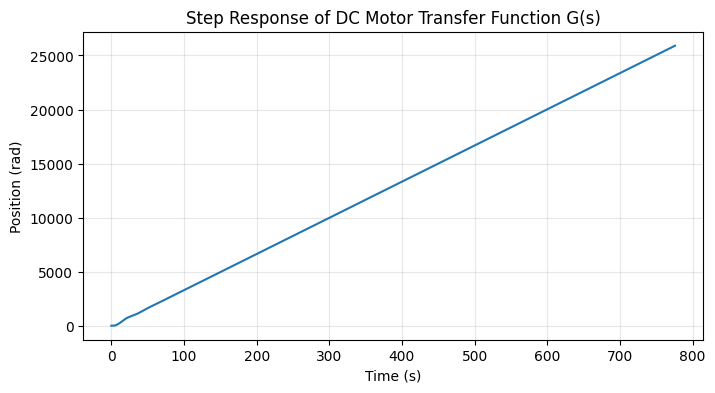

In [19]:
# Plot step response of G
t, y = ct.step_response(G)
plt.figure(figsize=(8, 4))
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Position (rad)")
plt.title("Step Response of DC Motor Transfer Function G(s)")
plt.grid(True, alpha=0.3)
plt.show()


### Define the Closed-Loop Transfer Function

With the transfer function of the plant identified, the closed-loop transfer function can be generated. You can derive this from the block diagram.

The closed-loop transfer function $C$ can be easily derived from the block diagram to be

$$C = \frac{Y}{R} = \frac{DG}{1 + DG}$$

The plant transfer function $G$ was identified in the previous section. The controller transfer function $D$ must also be known. A PID controller computes the control signal as

$$u(t) = k_p e + k_i \int_0^t e(\tau) d\tau + k_d \frac{de}{dt}$$

You can compute the controller transfer function $D$ by taking the Laplace transform and then solving for the ratio of the input error $E(s)$ to the output control signal $U(s)$:

$$D(s) = \frac{U(s)}{E(s)} = k_p + \frac{k_i}{s} + k_d s$$

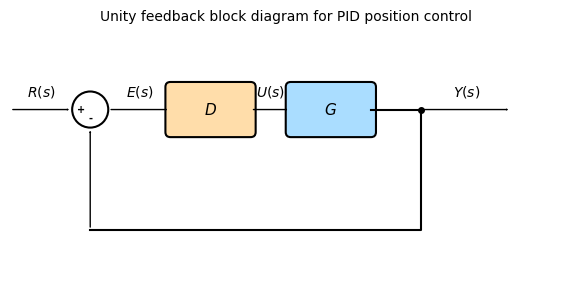

In [20]:
fig, ax = plt.subplots(figsize=(8, 3))
setup_axes(ax, (0, 5.5), (0, 2.5))

# Summing junction
s = Summer(0.8, 1.7, left="+", bottom="-")
# Controller block
d = Block(2.0, 1.7, "$D$", w=0.8, h=0.45, facecolor="#FFDDAA")
# Plant block
g = Block(3.2, 1.7, "$G$", w=0.8, h=0.45, facecolor="#AADDFF")

draw_summing_obj(ax, s)
draw_block_obj(ax, d)
draw_block_obj(ax, g)

# Input arrow
draw_connection(ax, (0, 1.7), s.entry_left, "$R(s)$")
# Summing junction to controller
draw_connection(ax, s.exit, d.center_left, "$E(s)$")
# Controller to plant
draw_connection(ax, d.center_right, g.center_left, "$U(s)$")

# Plant output and take-off point
jx = g.right + 0.5
draw_line(ax, [g.center_right, (jx, 1.7)])
draw_connection(ax, (jx, 1.7), (5.0, 1.7), "$Y(s)$")
draw_dot(ax, (jx, 1.7))

# Feedback path from take-off back to summing junction
draw_line(ax, [(jx, 1.7), (jx, 1.7 - 1.2), (s.x, 1.7 - 1.2)])
draw_connection(ax, (s.x, 1.7 - 1.2), s.entry_bottom)

ax.set_title("Unity feedback block diagram for PID position control", fontsize=10)
fig.tight_layout()
plt.show()


**Task 3.** With the parameters $k_p = 1$, $k_i = 0.1$, and $k_d = 0.1$, compute the PID transfer function $D$.

*Hint:* define the Laplace variable $s$ using `s = ct.TransferFunction.s`. Then use the variable `s` with standard arithmetic operations to define $D$. Remember the formula for the PID controller as a function of s!

In [21]:
# Write your code to define D here
kp = 1
ki = 0.1
kd = 0.1

s = None  # TODO: DEFINE THIS VARIABLE!
D = None  # TODO: DEFINE THIS VARIABLE!
print("D(s) =", D)


D(s) = None


**Task 4.** Compute the closed-loop transfer function $C$ for the PID position control of the DC motor using the transfer functions $G$ and $D$ you defined in the previous two tasks.

*Note:* It is possible to compute the closed-loop transfer function as $C = DG/(1+DG)$. However, this formula will generate an unnecessarily complicated expression. Instead, use the `ct.feedback` function. The syntax for `ct.feedback` is:

```python
sys = ct.feedback(sys1, sys2)
```

where `sys1` is the feedforward transfer function and `sys2` is the feedback transfer function. For this model, the feedback transfer function `sys2` should be set to `1`.

In [22]:
# Use ct.feedback to define C here
C = None  # TODO: Define this variable!
print("C(s) =", C)


C(s) = None


**Task 5.** Compute and plot the step response of the closed-loop transfer function $C$ using `ct.step_response` and `plt.plot`. If correct, your answer should show a well-behaved response.

In [23]:
# Write your code here
t, y = ct.step_response(C)
plt.figure(figsize=(8, 4))
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Position (rad)")
plt.title("Step Response of Closed-Loop Transfer Function C(s)")
plt.grid(True, alpha=0.3)
plt.show()


ValueError: can't automatically compute T for non-LTI system

**Task 6.** Based on the step response you observed in Task 5, do you think the closed-loop transfer function is stable?

In [ ]:
task6 = "-"  # TODO: Replace with "yes" or "no"
print("Is C(s) stable?", task6)


## Stability of the Feedback Controller

The **poles** of a rational transfer function occur where the denominator is zero. Consider a transfer function in factored form:

$$G(s) = K \frac{(s-z_1)(s-z_2)\ldots(s-z_m)}{(s-p_1)(s-p_2)\ldots(s-p_n)}$$

The poles are $p_1, p_2, \ldots, p_n$. Recall that the poles of a transfer function determine its general behavior and stability.

If all the poles of a transfer function lie in the left-half plane ($\text{Re}(p) < 0$), then the transfer function is stable. In this section, you will assess the stability of the feedback controller by examining the poles of its closed-loop transfer function.

**Task 7.** Compute the poles of the closed-loop transfer function $C$. Computing the poles by hand is challenging. Instead, use the `.poles()` method.

In [ ]:
# Write your code here
task7 = None  # TODO: define this!
print("Poles of C(s):")
for p in task7:
    print(f"  {p:.4f}")


**Task 8.** Based on the poles computed in Task 7, is the closed-loop transfer function stable?

In [ ]:
task8 = "-"  # TODO: replace with "yes" or "no"
print("Is C(s) stable based on poles?", task8)


**Task 9.** It can be helpful to visualise the poles (and zeros) of the system in the complex plane. Use the `ct.pzmap` function to plot the poles and zeros. Additionally, you can set the real and imaginary axis limits to $[-10, 10]$ using `plt.xlim` and `plt.ylim`.

In [ ]:
# TODO: write your code here